In [ ]:
!pip install nbconvert

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  si

C:\Users\Bhautik\AppData\Local\Temp\ipykernel_18436\1936577200.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_data, x="label", palette="viridis")


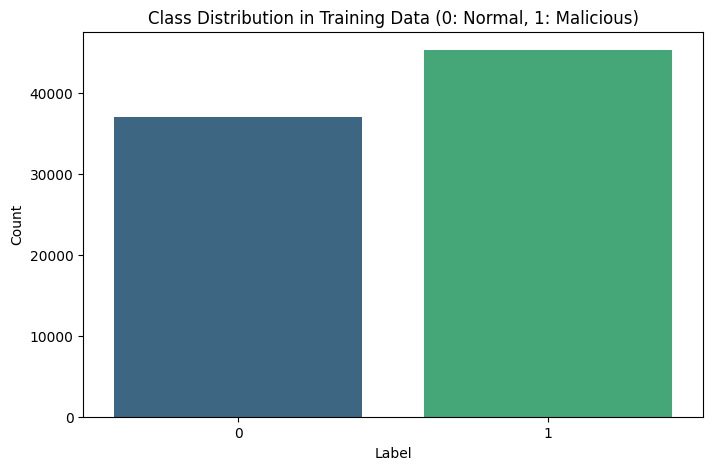

C:\Users\Bhautik\AppData\Local\Temp\ipykernel_18436\1936577200.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_data, x="proto", order=train_data["proto"].value_counts().index[:10], palette="Set2")


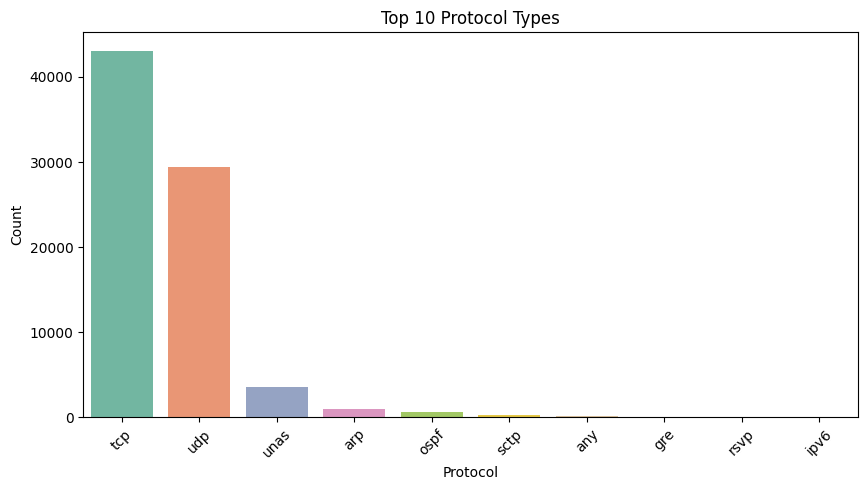

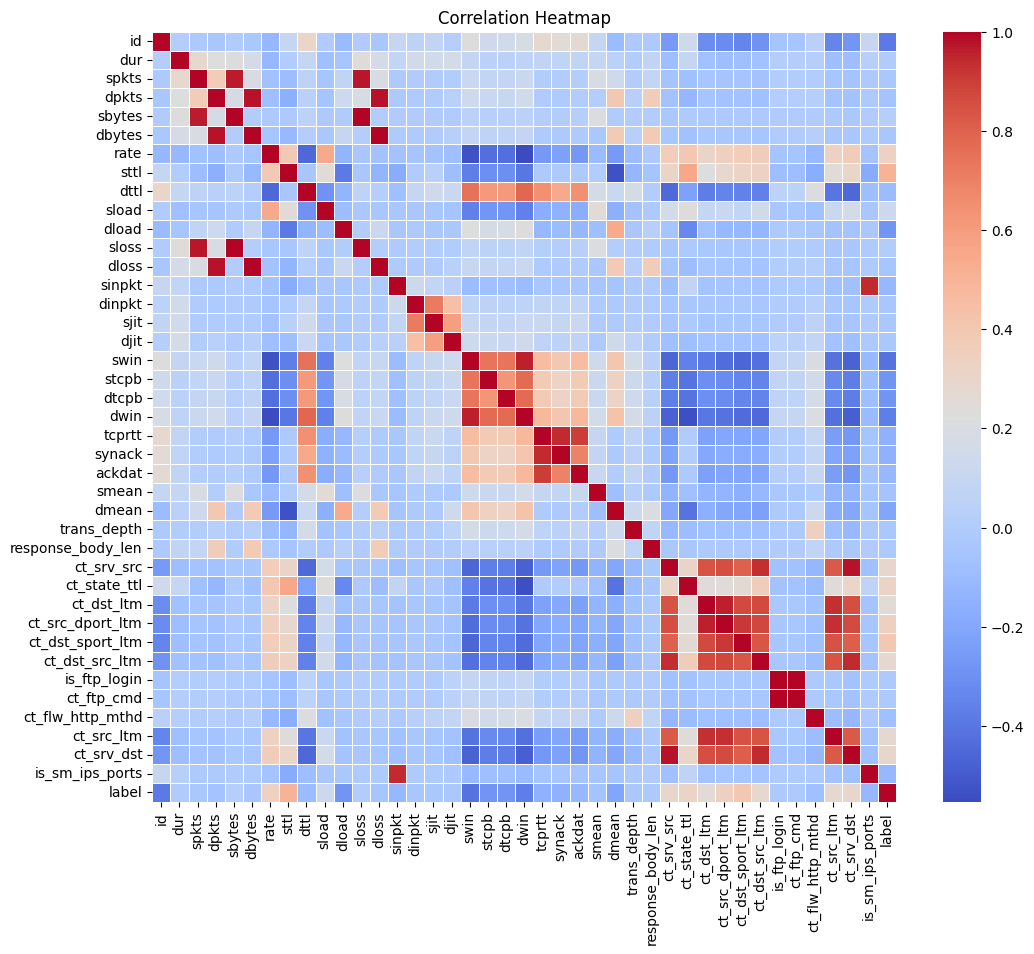

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load training and testing datasets
train_path = "UNSW_NB15_training-set.csv"
test_path = "UNSW_NB15_testing-set.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Display basic info
print("Training Data Info:")
print(train_data.info())

print("\nSample Training Data:")
print(train_data.head())

# Check for missing values
print("\nMissing Values:")
print(train_data.isnull().sum())

# Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=train_data, x="label", palette="viridis")
plt.title("Class Distribution in Training Data (0: Normal, 1: Malicious)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# Visualize protocol types
plt.figure(figsize=(10, 5))
sns.countplot(data=train_data, x="proto", order=train_data["proto"].value_counts().index[:10], palette="Set2")
plt.title("Top 10 Protocol Types")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap
numeric_columns = train_data.select_dtypes(include=["float64", "int64"]).columns
correlation_matrix = train_data[numeric_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [3]:
# --- Cell 4: Common Data Preparation ---

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

# Load training and testing datasets
train_path = "UNSW_NB15_training-set.csv"
test_path = "UNSW_NB15_testing-set.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Drop unnecessary columns from both datasets
train_df = train_data.drop(["id", "attack_cat"], axis=1, errors="ignore")
test_df = test_data.drop(["id", "attack_cat"], axis=1, errors="ignore")

# Identify categorical columns
categorical_cols = train_df.select_dtypes(include=['object']).columns

# Use one-hot encoding to ensure columns are aligned
combined_data = pd.concat([train_df, test_df], axis=0)
encoded_data = pd.get_dummies(combined_data, columns=categorical_cols)

# Separate the combined data back into training and testing sets
X_train_df = encoded_data.iloc[:len(train_df)]
X_test_df = encoded_data.iloc[len(train_df):]

# Separate labels
y_train = X_train_df.pop('label')
y_test = X_test_df.pop('label')

# --- Feature Scaling ---
# Fit the scaler ONLY on the training data
scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_df), columns=X_train_df.columns)

# Use the SAME scaler to transform the test data
X_test = pd.DataFrame(scaler.transform(X_test_df), columns=X_test_df.columns)

print("Data preprocessing complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Data preprocessing complete.
X_train shape: (82332, 196)
X_test shape: (175341, 196)


C:\Users\Bhautik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
C:\Users\Bhautik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 0.0056 - val_loss: 0.0017
Epoch 2/10
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 6.4384e-04 - val_loss: 9.6716e-04
Epoch 3/10
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5.4900e-04 - val_loss: 8.3982e-04
Epoch 4/10
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 4.9301e-04 - val_loss: 4.2114e-04
Epoch 5/10
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 4.5327e-04 - val_loss: 3.4556e-04
Epoch 6/10
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 4.3154e-04 - val_loss: 3.1371e-04
Epoch 7/10
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 3.9914e-04 - val_loss: 3.7447e-04
Epoch 8/10
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 3.6492e-04 - val_loss: 3.6437e-04
Epoch 9/10
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 3.2900e-04 - val_loss: 3.0757e-04
Epoch 10/10
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 2.6805e-04 - val_loss: 2.8447e-04


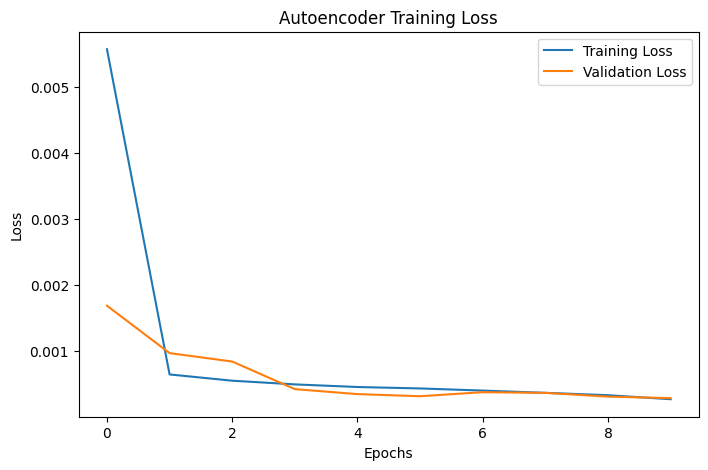

2573/2573 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
Anomaly Threshold: 0.0006742298399929782


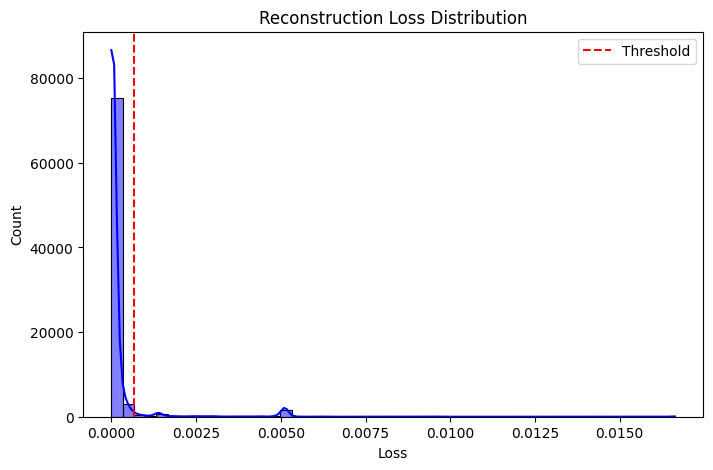

Number of anomalies detected: 4117


In [4]:
# --- Cell 5: Autoencoder for Anomaly Detection ---

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Build autoencoder
autoencoder = Sequential([
    Dense(64, activation="relu", input_dim=X_train.shape[1]),
    Dense(32, activation="relu"),
    Dense(64, activation="relu"),
    Dense(X_train.shape[1], activation="sigmoid")
])

autoencoder.compile(optimizer="adam", loss="mse")
history = autoencoder.fit(X_train, X_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Autoencoder Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Reconstruction loss for anomaly detection
reconstruction_loss = np.mean(np.square(X_train.values - autoencoder.predict(X_train)), axis=1)
threshold = np.percentile(reconstruction_loss, 95)  # Set threshold as 95th percentile
print(f"Anomaly Threshold: {threshold}")

# Visualize reconstruction loss
plt.figure(figsize=(8, 5))
sns.histplot(reconstruction_loss, bins=50, kde=True, color="blue")
plt.axvline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("Reconstruction Loss Distribution")
plt.xlabel("Loss")
plt.ylabel("Count")
plt.legend()
plt.show()

# Mark anomalies
anomalies = (reconstruction_loss > threshold).astype(int)
print(f"Number of anomalies detected: {np.sum(anomalies)}")


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Bhautik\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.98      0.87     56000
           1       0.99      0.87      0.93    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.90    175341
weighted avg       0.92      0.90      0.91    175341


Confusion Matrix:
[[ 54733   1267]
 [ 15472 103869]]


<Figure size 800x600 with 0 Axes>

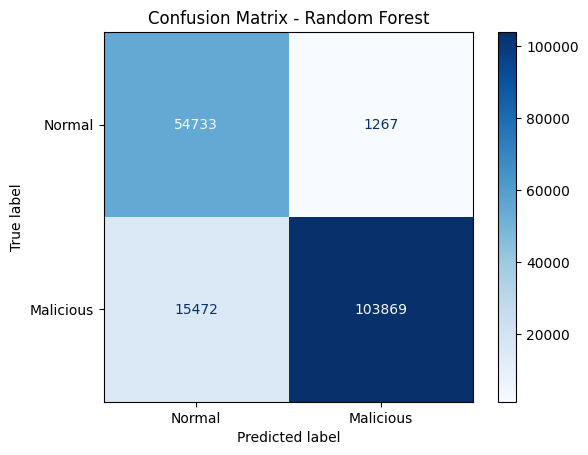


Accuracy: 0.9045


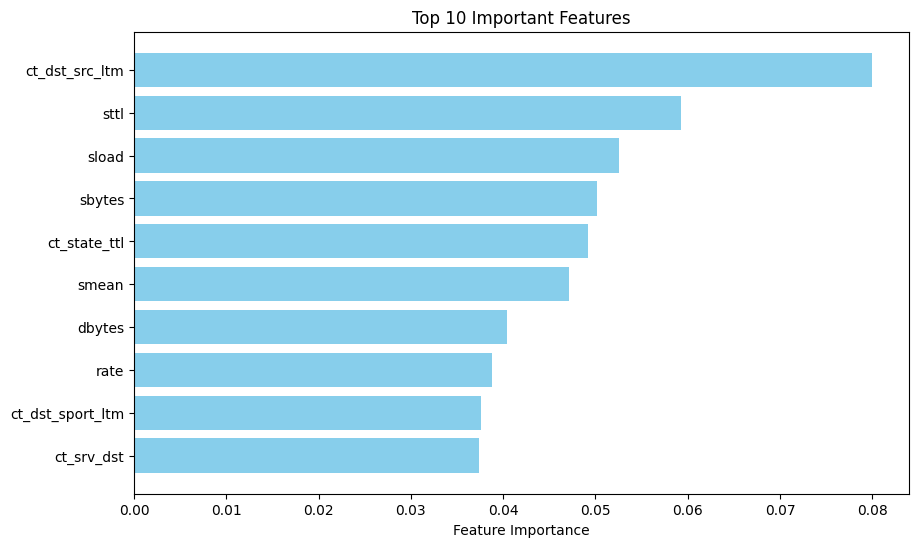


SHAP Summary Plot:


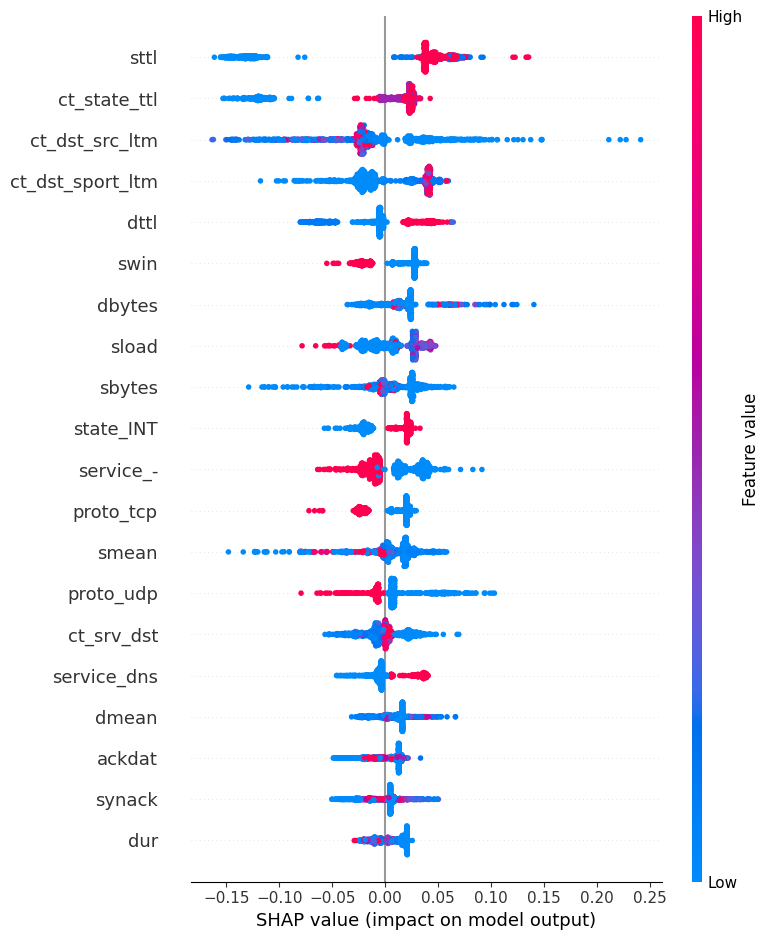


SHAP Waterfall Plot (for a single prediction):


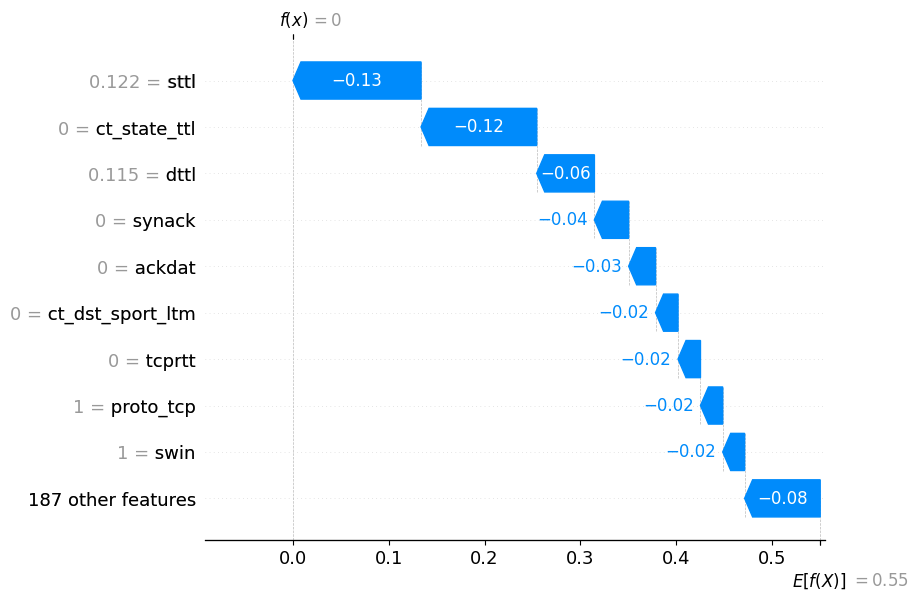

In [7]:
# --- Cell 6: Random Forest Classifier and SHAP ---

!pip install shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import shap
import matplotlib.pyplot as plt
import numpy as np 

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Classification metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Malicious"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")

# Visualize feature importance
feature_importance = rf_model.feature_importances_
features = X_train.columns
sorted_idx = np.argsort(feature_importance)[-10:]  # Top 10 features

plt.figure(figsize=(10, 6))
plt.barh(features[sorted_idx], feature_importance[sorted_idx], color="skyblue")
plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features")
plt.show()

# --- SHAP Analysis ---
# Using a smaller sample for faster computation
X_test_sample = X_test.sample(n=1000, random_state=42)

explainer = shap.TreeExplainer(rf_model)

# FIX: Use explainer(X) instead of explainer.shap_values(X)
# This returns a shap.Explanation object which automatically handles data alignment
shap_explanation = explainer(X_test_sample)

# Check shape to handle binary classification (Samples, Features, Classes)
# We want the values for Class 1 (the positive class)
if len(shap_explanation.shape) == 3:
    shap_values = shap_explanation[:, :, 1]
else:
    shap_values = shap_explanation

print("\nSHAP Summary Plot:")
# Pass the Explanation object directly. It contains both values and data.
shap.summary_plot(shap_values, X_test_sample)

print("\nSHAP Waterfall Plot (for a single prediction):")
# Pass the Explanation object for the first sample (index 0)
shap.waterfall_plot(shap_values[0])